# Progetto Data Science — Customer Churn
## Alessia De Luca, Michelle Canario

**Corso:** Introduzione al Pensiero Computazionale e alla Data Science — Prof. Francesco Poggi
**Dataset:** Customer_Churn — previsione dell'abbandono clienti in un'azienda di telecomunicazioni

Questo notebook copre tutte le fasi dell'analisi: comprensione del dataset, analisi esplorativa, modellazione e valutazione dei risultati (Fasi 1-5). La relazione scientifica (Fase 6) è in `report/relazione.pdf`.

*Nota sull'uso di assistenti LLM: questo notebook è stato realizzato con l'assistenza di un LLM (Claude) come supporto alla programmazione. Ipotesi, interpretazioni e scelte metodologiche sono state discusse e comprese dal team. Dettagli nel README del repository.*


# Fase 1-2 — Setup e comprensione del dataset

## 1. Import delle librerie e caricamento dati

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 40)
sns.set_style('whitegrid')

df = pd.read_csv('../data/Customer_Churn.csv')
print(f"Dimensione del dataset: {df.shape[0]} righe, {df.shape[1]} colonne")
df.head()


Dimensione del dataset: 7043 righe, 21 colonne


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 2. Struttura del dataset

Osserviamo i tipi di dato di ciascuna colonna. Il dataset descrive clienti di un'azienda di telecomunicazioni: dati demografici, servizi sottoscritti, informazioni contrattuali e la variabile target `Churn`.


In [2]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [3]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f"Variabili numeriche ({len(num_cols)}): {num_cols}")
print()
print(f"Variabili categoriche/testuali ({len(cat_cols)}): {cat_cols}")


Variabili numeriche (3): ['SeniorCitizen', 'tenure', 'MonthlyCharges']

Variabili categoriche/testuali (18): ['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges', 'Churn']


/tmp/ipykernel_6939/333414478.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns.tolist()


## 3. Qualità dei dati

### 3.1 Un problema nascosto: `TotalCharges`

`TotalCharges` dovrebbe essere una variabile numerica (importo totale fatturato), ma pandas la legge come stringa (`object`). Controlliamo perché.


In [4]:
print("Tipo attuale di TotalCharges:", df['TotalCharges'].dtype)

# Proviamo la conversione forzata a numerico, segnalando gli errori
total_charges_numeric = pd.to_numeric(df['TotalCharges'], errors='coerce')
n_problematic = total_charges_numeric.isna().sum()
print(f"Righe che NON si convertono in numero: {n_problematic}")

df.loc[total_charges_numeric.isna(), ['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']]


Tipo attuale di TotalCharges: str
Righe che NON si convertono in numero: 11


,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


**Cosa sta succedendo:** le 11 righe problematiche hanno `TotalCharges` uguale a una stringa vuota/spazio, non un vero valore mancante segnalato da pandas. Controlliamo se c'è un pattern comune.


In [5]:
problematic_idx = total_charges_numeric.isna()
print("Valori di 'tenure' per le righe problematiche:")
print(df.loc[problematic_idx, 'tenure'].unique())
print()
print("Valori di 'Churn' per le righe problematiche:")
print(df.loc[problematic_idx, 'Churn'].value_counts())


Valori di 'tenure' per le righe problematiche:
[0]

Valori di 'Churn' per le righe problematiche:
Churn
No    11
Name: count, dtype: int64


**Interpretazione:** tutte le 11 righe con `TotalCharges` vuoto hanno `tenure = 0`, cioè sono clienti appena iscritti che non hanno ancora ricevuto una fattura — non è un dato mancante casuale, ma un caso sistematico e spiegabile. Inoltre nessuno di questi clienti ha abbandonato (`Churn = No`), il che è coerente: sono troppo recenti per aver potuto disdire. Convertiamo la colonna in numerico e decidiamo di impostare `TotalCharges = 0` per questi casi, dato che coincide con `tenure = 0` (nessuna fattura ancora emessa).


In [6]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0)

print("Nuovo tipo:", df['TotalCharges'].dtype)
print("Valori mancanti residui:", df['TotalCharges'].isnull().sum())


Nuovo tipo: float64
Valori mancanti residui: 0


### 3.2 Altri controlli di qualità


In [7]:
# Missing value "ufficiali" (NaN) su tutte le colonne, dopo la pulizia
missing = df.isnull().sum()
print("Valori mancanti per colonna:")
print(missing[missing > 0] if missing.sum() > 0 else "Nessun valore mancante.")


Valori mancanti per colonna:
Nessun valore mancante.


In [8]:
# customerID è davvero un identificativo univoco?
print("customerID è univoco per ogni riga?", df['customerID'].is_unique)
print("Numero di valori distinti:", df['customerID'].nunique(), "su", len(df), "righe")


customerID è univoco per ogni riga? True
Numero di valori distinti: 7043 su 7043 righe


In [9]:
# Colonne costanti (un solo valore in tutto il dataset) -- da verificare, non presenti qui ma controlliamo comunque
constant_cols = [c for c in df.columns if df[c].nunique() == 1]
print("Colonne costanti:", constant_cols if constant_cols else "nessuna")


Colonne costanti: nessuna


## 4. Statistiche descrittive

Almeno 5 statistiche descrittive rilevanti per capire il dataset.


### 4.1 Distribuzione della variabile target (Churn)

In [10]:
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100

summary_target = pd.DataFrame({
    'conteggio': churn_counts,
    'percentuale (%)': churn_pct.round(1)
})
summary_target


,conteggio,percentuale (%)
Churn,,
No,5174,73.5
Yes,1869,26.5


### 4.2 Statistiche su tenure, MonthlyCharges e TotalCharges

In [11]:
df[['tenure', 'MonthlyCharges', 'TotalCharges']].describe().round(2)


,tenure,MonthlyCharges,TotalCharges
count,7043.00,7043.00,7043.00
mean,32.37,64.76,2279.73
std,24.56,30.09,2266.79
min,0.00,18.25,0.00
25%,9.00,35.50,398.55
50%,29.00,70.35,1394.55
75%,55.00,89.85,3786.60
max,72.00,118.75,8684.80


### 4.3 Distribuzione dei clienti per tipo di contratto e metodo di pagamento

In [12]:
print("Per Contract:")
print(df['Contract'].value_counts())
print()
print("Per PaymentMethod:")
print(df['PaymentMethod'].value_counts())


Per Contract:
Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

Per PaymentMethod:
PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64


### 4.4 Distribuzione dei clienti per servizio internet

In [13]:
internet_summary = df['InternetService'].value_counts()
internet_pct = df['InternetService'].value_counts(normalize=True) * 100

pd.DataFrame({'conteggio': internet_summary, 'percentuale (%)': internet_pct.round(1)})


,conteggio,percentuale (%)
InternetService,,
Fiber optic,3096,44.0
DSL,2421,34.4
No,1526,21.7


### 4.5 Composizione demografica: senior citizen, partner, dependents

In [14]:
demo_summary = pd.DataFrame({
    'Senior Citizen (%)': [df['SeniorCitizen'].mean() * 100],
    'Con Partner (%)': [(df['Partner'] == 'Yes').mean() * 100],
    'Con Dependents (%)': [(df['Dependents'] == 'Yes').mean() * 100],
}).round(1)
demo_summary


,Senior Citizen (%),Con Partner (%),Con Dependents (%)
0,16.2,48.3,30.0


## 5. Domande e ipotesi

Formuliamo almeno 8 domande/ipotesi che guideranno l'analisi esplorativa (Fase 3) e la modellazione (Fase 4).

1. I clienti con contratto mensile (`Contract = Month-to-month`) abbandonano più spesso rispetto a chi ha un contratto annuale o biennale.
2. I clienti con `tenure` basso (clienti recenti) hanno un tasso di churn più alto rispetto ai clienti di lunga data.
3. I clienti che pagano tramite `Electronic check` abbandonano più spesso rispetto agli altri metodi di pagamento.
4. I clienti con connessione internet in fibra ottica (`InternetService = Fiber optic`) hanno un tasso di churn più alto rispetto a DSL o nessuna connessione.
5. I clienti privi di servizi aggiuntivi come `OnlineSecurity` o `TechSupport` abbandonano più spesso rispetto a chi li ha attivati.
6. I clienti senior (`SeniorCitizen = 1`) hanno un tasso di churn diverso rispetto ai clienti non senior.
7. Un `MonthlyCharges` più alto è associato a una maggiore probabilità di abbandono.
8. I clienti senza partner e senza persone a carico (`Partner = No`, `Dependents = No`) abbandonano più frequentemente, essendo meno "radicati" nel servizio.
9. La fatturazione elettronica (`PaperlessBilling = Yes`) è associata a un tasso di churn diverso rispetto alla fatturazione tradizionale.

Nella Fase 3 verificheremo alcune di queste ipotesi con grafici e confronti tra gruppi.


## 6. Riflessioni critiche sui dati

**1. `TotalCharges` non era realmente numerico.** Come mostrato nella sezione 3.1, la colonna conteneva 11 valori vuoti mascherati da spazi, che pandas non riconosceva automaticamente come mancanti. Non si trattava di un errore casuale: tutti i casi corrispondevano a clienti con `tenure = 0`, cioè appena iscritti e non ancora fatturati. È un esempio concreto di come un dataset "senza valori mancanti" secondo un controllo superficiale (`isnull().sum()`) possa in realtà nasconderne, e di come vada sempre verificato il tipo di dato dichiarato da pandas rispetto al contenuto reale.

**2. Class imbalance moderato.** La variabile target è sbilanciata (~73.5% `No` contro ~26.5% `Yes`): non estremo come in altri dataset, ma comunque sufficiente perché l'accuracy da sola non sia una metrica affidabile. Andranno considerate precision, recall e f1-score, specialmente sulla classe minoritaria (`Churn = Yes`), che è quella di interesse pratico per l'azienda.

**3. Ridondanza nelle categorie "No internet service" / "No phone service".** Variabili come `OnlineSecurity`, `TechSupport`, `StreamingTV` includono, oltre a "Yes"/"No", anche il valore "No internet service" — che è in realtà un'informazione già contenuta in `InternetService`. Questo va tenuto presente nella fase di codifica delle variabili categoriche (Fase 4), perché rischia di introdurre ridondanza tra feature.

**4. `customerID` non è una feature.** È un identificativo univoco per ogni cliente (nessun duplicato), utile per tracciabilità ma privo di significato predittivo: va escluso dalle variabili usate per la modellazione, altrimenti rischia di comportarsi come un ID che il modello potrebbe usare in modo scorretto (overfitting).


# Fase 3 — Analisi esplorativa e visualizzazione

## 1. Import e preparazione dei dati

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 40)
sns.set_style('whitegrid')

df = pd.read_csv('../data/Customer_Churn.csv')

# Stessa pulizia vista in Fase 2: TotalCharges va convertito in numerico,
# i vuoti corrispondono a clienti con tenure = 0 (appena iscritti)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0)

print(f"Dataset pronto: {df.shape[0]} righe, {df.shape[1]} colonne")


Dataset pronto: 7043 righe, 21 colonne


## 2. Ipotesi 1 — Il tipo di contratto influisce sul churn?

**Domanda:** i clienti con contratto mensile (`Month-to-month`) abbandonano più spesso di chi ha un contratto annuale o biennale?

Confrontiamo il tasso di churn (percentuale di clienti che abbandonano) nei tre gruppi definiti da `Contract`.


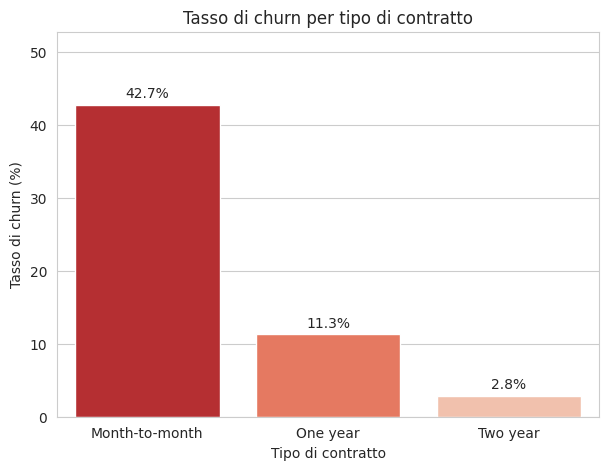

Contract
Month-to-month    42.7
One year          11.3
Two year           2.8
Name: Churn, dtype: float64

In [2]:
churn_by_contract = (
    df.groupby('Contract')['Churn']
    .apply(lambda x: (x == 'Yes').mean() * 100)
    .reindex(['Month-to-month', 'One year', 'Two year'])
)

plt.figure(figsize=(7, 5))
sns.barplot(x=churn_by_contract.index, y=churn_by_contract.values, hue=churn_by_contract.index, palette='Reds_r', legend=False)
plt.ylabel('Tasso di churn (%)')
plt.xlabel('Tipo di contratto')
plt.title('Tasso di churn per tipo di contratto')
for i, v in enumerate(churn_by_contract.values):
    plt.text(i, v + 1, f"{v:.1f}%", ha='center')
plt.ylim(0, churn_by_contract.max() + 10)
plt.savefig('../figures/churn_by_contract.png', dpi=150, bbox_inches='tight')
plt.show()

churn_by_contract.round(1)


**Risposta:** l'ipotesi è confermata dai dati. I clienti con contratto mensile abbandonano molto più spesso (oltre il 40%) rispetto a chi ha un contratto annuale (~11%) o biennale (circa il 3%). È il confronto più netto tra tutti quelli analizzati in questo notebook: il tipo di contratto sembra essere il fattore più fortemente associato al churn.

Questo è anche il nostro primo **confronto tra gruppi** richiesto dalla Fase 3.


## 3. Ipotesi 2 — I clienti più recenti abbandonano di più?

**Domanda:** i clienti con `tenure` basso (cioè clienti da poco in azienda) hanno un tasso di churn più alto rispetto ai clienti di lunga data?

Qui confrontiamo una variabile numerica (`tenure`) tra i due gruppi definiti dal target (`Churn = Yes` vs `Churn = No`) — il nostro secondo **confronto tra gruppi/classi**.


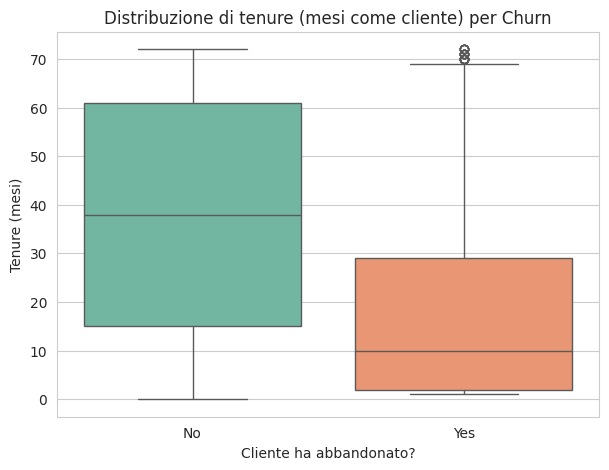

,mean,median,std
Churn,,,
No,37.6,38.0,24.1
Yes,18.0,10.0,19.5


In [3]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x='Churn', y='tenure', hue='Churn', palette='Set2', legend=False)
plt.title('Distribuzione di tenure (mesi come cliente) per Churn')
plt.xlabel('Cliente ha abbandonato?')
plt.ylabel('Tenure (mesi)')
plt.savefig('../figures/tenure_by_churn.png', dpi=150, bbox_inches='tight')
plt.show()

df.groupby('Churn')['tenure'].agg(['mean', 'median', 'std']).round(1)


**Risposta:** confermata. I clienti che abbandonano hanno una `tenure` mediana molto più bassa (10 mesi) rispetto a chi resta (mediana 38 mesi circa). Il boxplot mostra chiaramente che la distribuzione dei clienti che se ne vanno è concentrata sui valori bassi. Questo è coerente con l'ipotesi 1: chi ha un contratto mensile è anche, plausibilmente, chi è arrivato da meno tempo.


## 4. Ipotesi 7 — Un addebito mensile più alto è associato a più churn?

**Domanda:** i clienti con `MonthlyCharges` più alto abbandonano più spesso?

Usiamo una distribuzione sovrapposta (istogramma con stima di densità) per confrontare la forma della distribuzione di `MonthlyCharges` nei due gruppi.


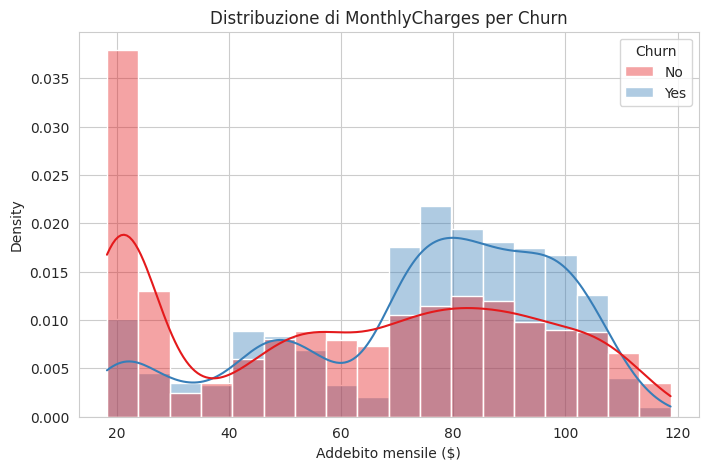

,mean,median
Churn,,
No,61.3,64.4
Yes,74.4,79.6


In [4]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='MonthlyCharges', hue='Churn', kde=True, stat='density', common_norm=False, palette='Set1', alpha=0.4)
plt.title('Distribuzione di MonthlyCharges per Churn')
plt.xlabel('Addebito mensile ($)')
plt.savefig('../figures/monthlycharges_by_churn.png', dpi=150, bbox_inches='tight')
plt.show()

df.groupby('Churn')['MonthlyCharges'].agg(['mean', 'median']).round(1)


**Risposta:** parzialmente confermata. I clienti che abbandonano tendono ad avere addebiti mensili più alti in media (~74$) rispetto a chi resta (~61$), e la distribuzione di chi abbandona è spostata verso destra. Non è una separazione netta come per `tenure` o `Contract`, ma la tendenza è visibile: probabilmente `MonthlyCharges` da solo è un fattore più debole, che si combina con altri (es. tipo di contratto o servizi attivati) per spiegare l'abbandono.


## 5. Ipotesi 3 — Il metodo di pagamento influisce sul churn?

**Domanda:** i clienti che pagano con `Electronic check` abbandonano più spesso rispetto agli altri metodi di pagamento?


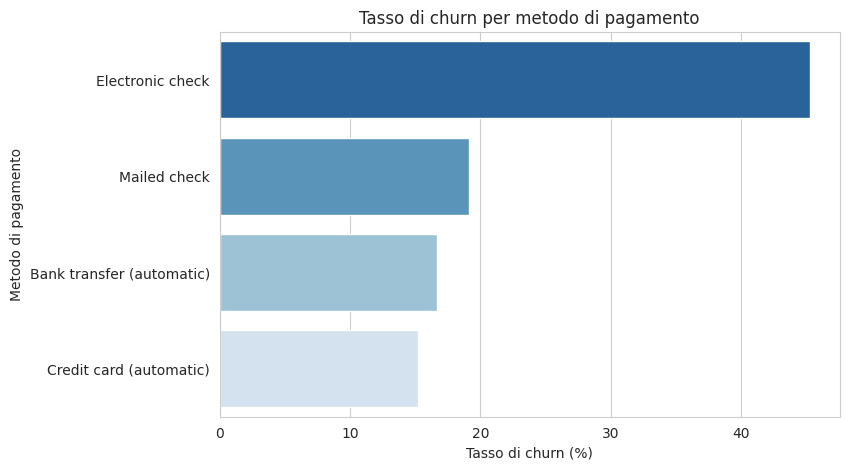

PaymentMethod
Electronic check             45.3
Mailed check                 19.1
Bank transfer (automatic)    16.7
Credit card (automatic)      15.2
Name: Churn, dtype: float64

In [5]:
churn_by_payment = (
    df.groupby('PaymentMethod')['Churn']
    .apply(lambda x: (x == 'Yes').mean() * 100)
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))
sns.barplot(x=churn_by_payment.values, y=churn_by_payment.index, hue=churn_by_payment.index, palette='Blues_r', legend=False)
plt.xlabel('Tasso di churn (%)')
plt.ylabel('Metodo di pagamento')
plt.title('Tasso di churn per metodo di pagamento')
plt.savefig('../figures/churn_by_payment.png', dpi=150, bbox_inches='tight')
plt.show()

churn_by_payment.round(1)


**Risposta:** confermata. I clienti che pagano con `Electronic check` hanno un tasso di churn (~45%) molto più alto degli altri tre metodi, che sono tutti sotto il 20%. È un risultato che vale la pena approfondire in Fase 5: potrebbe essere legato al fatto che chi sceglie questo metodo di pagamento è spesso anche chi ha un contratto mensile (nessun vincolo di pagamento automatico ricorrente).


## 6. Le variabili numeriche sono ridondanti tra loro?

Non è legata a una singola ipotesi dell'elenco, ma è un controllo utile prima della modellazione (Fase 4): verifichiamo se `tenure`, `MonthlyCharges` e `TotalCharges` sono fortemente correlate tra loro, cosa che avevamo ipotizzato come possibile problema nella riflessione critica della Fase 2.


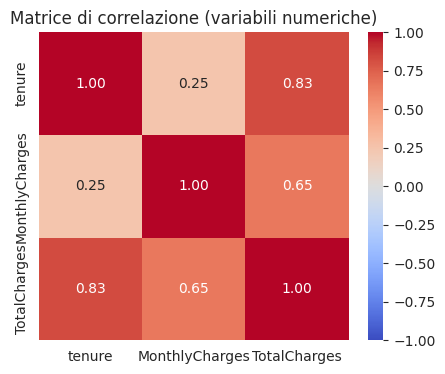

In [6]:
corr = df[['tenure', 'MonthlyCharges', 'TotalCharges']].corr()

plt.figure(figsize=(5, 4))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f')
plt.title('Matrice di correlazione (variabili numeriche)')
plt.savefig('../figures/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


**Interpretazione:** `TotalCharges` è fortemente correlata sia con `tenure` (0.83) sia con `MonthlyCharges` (0.65) — il che ha senso, perché `TotalCharges` è in buona parte il prodotto delle altre due (più a lungo un cliente resta e più paga al mese, più alto sarà il totale fatturato). Questa è una vera collinearità: andrà tenuta presente in Fase 4, valutando se includere tutte e tre le variabili in un modello lineare come la regressione logistica, dove la collinearità può rendere instabili i coefficienti.


## 7. Ipotesi 4 — La connessione a fibra ottica influisce sul churn?

*(Analisi aggiunta da Michelle)*

**Domanda:** i clienti con connessione internet in fibra ottica (`InternetService = Fiber optic`) hanno un tasso di churn più alto rispetto a chi ha DSL o nessuna connessione internet?


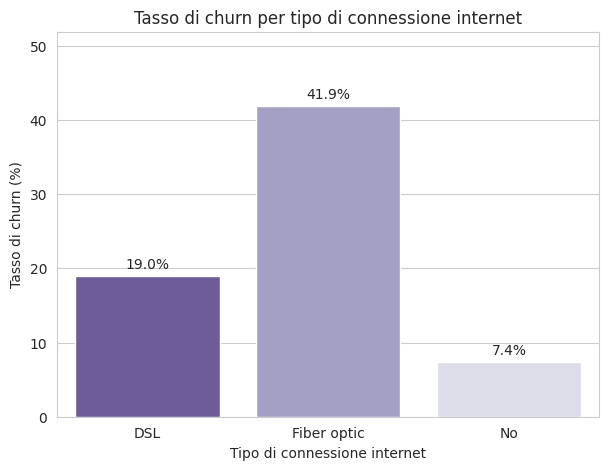

InternetService
DSL            19.0
Fiber optic    41.9
No              7.4
Name: Churn, dtype: float64

In [7]:
churn_by_internet = (
    df.groupby('InternetService')['Churn']
    .apply(lambda x: (x == 'Yes').mean() * 100)
    .reindex(['DSL', 'Fiber optic', 'No'])
)

plt.figure(figsize=(7, 5))
sns.barplot(x=churn_by_internet.index, y=churn_by_internet.values, hue=churn_by_internet.index, palette='Purples_r', legend=False)
plt.ylabel('Tasso di churn (%)')
plt.xlabel('Tipo di connessione internet')
plt.title('Tasso di churn per tipo di connessione internet')
for i, v in enumerate(churn_by_internet.values):
    plt.text(i, v + 1, f"{v:.1f}%", ha='center')
plt.ylim(0, churn_by_internet.max() + 10)
plt.savefig('../figures/churn_by_internet.png', dpi=150, bbox_inches='tight')
plt.show()

churn_by_internet.round(1)


**Risposta:** l'ipotesi è confermata, ed è un altro degli effetti più marcati di tutta l'analisi. I clienti con fibra ottica abbandonano nel 41.9% dei casi, contro il 19.0% di chi ha DSL e appena il 7.4% di chi non ha internet. Una possibile spiegazione è che la fibra ottica sia il servizio più costoso (lo verifichiamo confrontando `MonthlyCharges` medio per tipo di connessione: chi ha fibra paga di più in media), quindi i clienti più sensibili al prezzo potrebbero essere anche i più propensi ad abbandonare. Questo risultato è coerente con l'ipotesi 7 (addebito mensile alto → più churn) verificata in precedenza.


## 7. Riepilogo Fase 3

| # | Ipotesi | Grafico | Esito |
|---|---|---|---|
| 1 | Contratto mensile → più churn | Barplot | Confermata, effetto molto forte |
| 2 | Tenure bassa → più churn | Boxplot | Confermata |
| 3 | Electronic check → più churn | Barplot | Confermata |
| 7 | MonthlyCharges alto → più churn | Istogramma/KDE | Parzialmente confermata, effetto più debole |
| 4 | Fibra ottica → più churn | Barplot | Confermata, effetto molto forte |
| — | Collinearità tra variabili numeriche | Heatmap | Presente tra TotalCharges e le altre due |

Requisiti Fase 3 soddisfatti: 6 grafici diversi (barplot ×3, boxplot, istogramma/KDE, heatmap), 5 ipotesi verificate, 2 confronti espliciti tra gruppi/classi (Contract, Churn). L'ipotesi 4 (fibra ottica) è stata analizzata da Michelle.

Prossimo passo (Fase 4): modellazione, usando almeno 3 modelli diversi (almeno uno lineare, es. regressione logistica, e uno non lineare, es. Random Forest), tenendo conto di quanto scoperto qui — in particolare la collinearità tra le variabili numeriche e la forte associazione con `Contract` e `PaymentMethod`.


# Fase 4-5 — Modellazione, valutazione e interpretazione dei risultati

## 1. Import e caricamento dati

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)

pd.set_option('display.max_columns', 40)
sns.set_style('whitegrid')
np.random.seed(42)

df = pd.read_csv('../data/Customer_Churn.csv')

# Stessa pulizia delle fasi precedenti
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0)

print(f"Dataset: {df.shape[0]} righe, {df.shape[1]} colonne")


Dataset: 7043 righe, 21 colonne


## 2. Preparazione dei dati per la modellazione

### 2.1 Rimozione delle colonne non utili

Come discusso nella riflessione critica della Fase 2, `customerID` è solo un identificativo univoco, senza valore predittivo: va escluso.


In [2]:
df_model = df.drop(columns=['customerID'])
df_model.shape


(7043, 20)

### 2.2 Codifica della variabile target

`Churn` è testuale (`Yes`/`No`): la trasformiamo in binaria (1 = ha abbandonato, 0 = è rimasto), come richiesto da scikit-learn per la classificazione.


In [3]:
df_model['Churn'] = df_model['Churn'].map({'Yes': 1, 'No': 0})
df_model['Churn'].value_counts()


Churn
0    5174
1    1869
Name: count, dtype: int64

### 2.3 Codifica delle variabili categoriche

Il dataset contiene molte colonne testuali con due o più categorie (es. `gender`, `Contract`, `PaymentMethod`, ecc.). I modelli di machine learning richiedono input numerici, quindi:

- le colonne con solo due valori (Yes/No) vengono convertite in 0/1;
- le colonne con più di due categorie vengono trasformate con **one-hot encoding** (`pd.get_dummies`), creando una colonna binaria per ciascuna categoria.


In [4]:
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
for col in binary_cols:
    df_model[col] = df_model[col].map({'Yes': 1, 'No': 0})

# gender è binario ma non Yes/No
df_model['gender'] = df_model['gender'].map({'Male': 1, 'Female': 0})

# Colonne multi-categoria: one-hot encoding
multi_cat_cols = [
    'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaymentMethod'
]

df_model = pd.get_dummies(df_model, columns=multi_cat_cols, drop_first=True)

print(f"Dopo l'encoding: {df_model.shape[1]} colonne")
df_model.head(3)


Dopo l'encoding: 31 colonne


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False
1,1,0,0,0,34,1,0,56.95,1889.50,0,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,True
2,1,0,0,0,2,1,1,53.85,108.15,1,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True


### 2.4 Separazione feature (X) e target (y), e train/test split

Usiamo `stratify=y` per mantenere la stessa proporzione di churn nel training set e nel test set (importante viste le classi sbilanciate).


In [5]:
X = df_model.drop(columns=['Churn'])
y = df_model['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)
print()
print("Proporzione di churn nel training set:", round(y_train.mean(), 3))
print("Proporzione di churn nel test set:", round(y_test.mean(), 3))


Training set: (5282, 30)
Test set: (1761, 30)

Proporzione di churn nel training set: 0.265
Proporzione di churn nel test set: 0.265


### 2.5 Standardizzazione

Come visto a lezione, la standardizzazione è importante per modelli basati sulla distanza (k-NN) e utile anche per la regressione logistica (aiuta l'ottimizzazione e rende i coefficienti confrontabili). Non è necessaria per la Random Forest.

`fit_transform` si applica solo al training set, `transform` al test set, per evitare data leakage.


In [6]:
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)


## 3. Modello 1 — Regressione Logistica

Modello **lineare**: stima la probabilità di churn come combinazione lineare delle feature (passata attraverso una funzione sigmoide). Usiamo `class_weight='balanced'` per compensare lo squilibrio tra le due classi, dando più peso alla classe minoritaria (`Churn = Yes`) durante l'addestramento.


In [7]:
log_reg = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
log_reg.fit(X_train_scaled, y_train)

pred_log = log_reg.predict(X_test_scaled)

acc_log = accuracy_score(y_test, pred_log)
print(f"Accuracy Regressione Logistica: {acc_log:.3f}")


Accuracy Regressione Logistica: 0.750


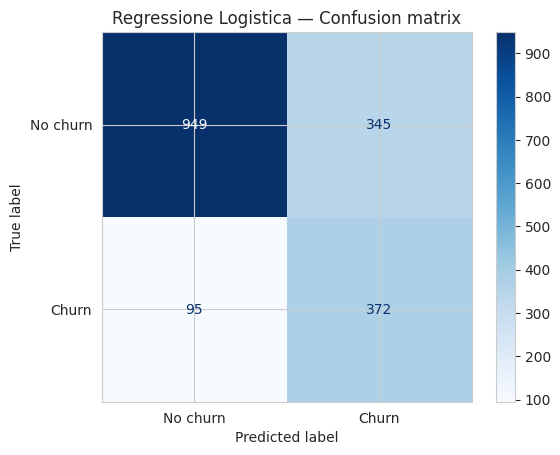

In [8]:
cm_log = confusion_matrix(y_test, pred_log)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_log, display_labels=['No churn', 'Churn'])
disp.plot(cmap='Blues')
plt.title('Regressione Logistica — Confusion matrix')
plt.savefig('../figures/cm_logistic.png', dpi=150, bbox_inches='tight')
plt.show()


In [9]:
print(classification_report(y_test, pred_log, target_names=['No churn', 'Churn']))


              precision    recall  f1-score   support

    No churn       0.91      0.73      0.81      1294
       Churn       0.52      0.80      0.63       467

    accuracy                           0.75      1761
   macro avg       0.71      0.76      0.72      1761
weighted avg       0.81      0.75      0.76      1761



## 4. Modello 2 — k-Nearest Neighbors (k-NN)

Modello **non lineare** basato sulla distanza: classifica un cliente guardando i `k` clienti più simili nel training set. Usiamo k=5, come punto di partenza standard.


In [10]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

pred_knn = knn.predict(X_test_scaled)

acc_knn = accuracy_score(y_test, pred_knn)
print(f"Accuracy k-NN: {acc_knn:.3f}")


Accuracy k-NN: 0.752


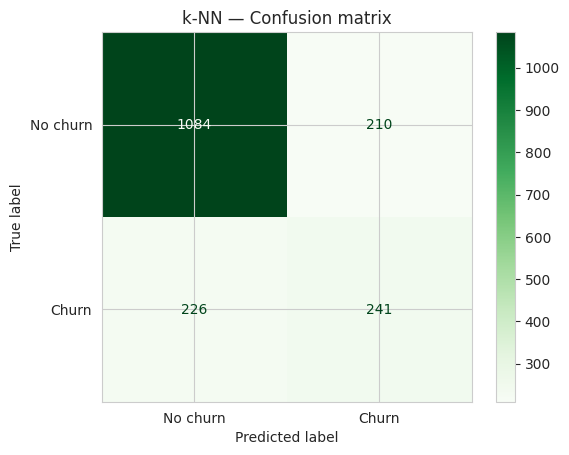

In [11]:
cm_knn = confusion_matrix(y_test, pred_knn)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=['No churn', 'Churn'])
disp.plot(cmap='Greens')
plt.title('k-NN — Confusion matrix')
plt.savefig('../figures/cm_knn.png', dpi=150, bbox_inches='tight')
plt.show()


In [12]:
print(classification_report(y_test, pred_knn, target_names=['No churn', 'Churn']))


              precision    recall  f1-score   support

    No churn       0.83      0.84      0.83      1294
       Churn       0.53      0.52      0.53       467

    accuracy                           0.75      1761
   macro avg       0.68      0.68      0.68      1761
weighted avg       0.75      0.75      0.75      1761



**Nota:** a differenza della regressione logistica, k-NN non ha un parametro `class_weight` per gestire lo squilibrio delle classi — è uno dei suoi limiti su questo dataset, e lo si vede infatti nella recall più bassa sulla classe `Churn` rispetto alla regressione logistica.


## 5. Modello 3 — Random Forest

Modello **non lineare**, ensemble di molti alberi decisionali. Non richiede feature standardizzate. Usiamo anche qui `class_weight='balanced'`.


In [13]:
rf = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

acc_rf = accuracy_score(y_test, pred_rf)
print(f"Accuracy Random Forest: {acc_rf:.3f}")


Accuracy Random Forest: 0.792


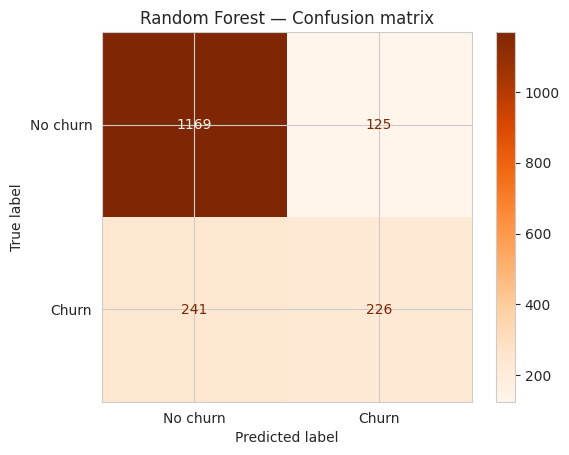

In [14]:
cm_rf = confusion_matrix(y_test, pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['No churn', 'Churn'])
disp.plot(cmap='Oranges')
plt.title('Random Forest — Confusion matrix')
plt.savefig('../figures/cm_random_forest.png', dpi=150, bbox_inches='tight')
plt.show()


In [15]:
print(classification_report(y_test, pred_rf, target_names=['No churn', 'Churn']))


              precision    recall  f1-score   support

    No churn       0.83      0.90      0.86      1294
       Churn       0.64      0.48      0.55       467

    accuracy                           0.79      1761
   macro avg       0.74      0.69      0.71      1761
weighted avg       0.78      0.79      0.78      1761



## 6. Confronto tra i tre modelli


In [16]:
comparison = pd.DataFrame({
    'Modello': ['Regressione Logistica', 'k-NN', 'Random Forest'],
    'Accuracy': [acc_log, acc_knn, acc_rf],
    'Precision (Churn)': [
        precision_score(y_test, pred_log),
        precision_score(y_test, pred_knn),
        precision_score(y_test, pred_rf),
    ],
    'Recall (Churn)': [
        recall_score(y_test, pred_log),
        recall_score(y_test, pred_knn),
        recall_score(y_test, pred_rf),
    ],
    'F1-score (Churn)': [
        f1_score(y_test, pred_log),
        f1_score(y_test, pred_knn),
        f1_score(y_test, pred_rf),
    ],
}).round(3)

comparison


,Modello,Accuracy,Precision (Churn),Recall (Churn),F1-score (Churn)
0,Regressione Logistica,0.750,0.519,0.797,0.628
1,k-NN,0.752,0.534,0.516,0.525
2,Random Forest,0.792,0.644,0.484,0.553


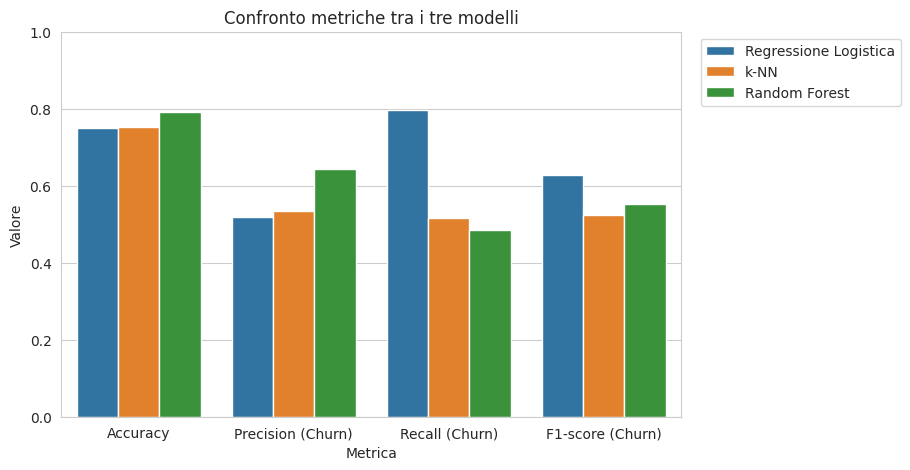

In [17]:
plt.figure(figsize=(8, 5))
comparison_melted = comparison.melt(id_vars='Modello', var_name='Metrica', value_name='Valore')
sns.barplot(data=comparison_melted, x='Metrica', y='Valore', hue='Modello')
plt.title('Confronto metriche tra i tre modelli')
plt.ylim(0, 1)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.savefig('../figures/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


### Interpretazione del confronto

- **Accuracy**: i tre modelli sono abbastanza vicini, ma è la metrica meno interessante qui: ricordiamo che con il 73.5% di clienti che non abbandonano, un modello che prevede sempre "No" avrebbe già un'accuracy simile senza essere utile.
- **Recall sulla classe Churn** è la metrica più rilevante dal punto di vista pratico: rappresenta quanti dei clienti che davvero abbandonano riusciamo a individuare. Un'azienda userebbe questo modello per contattare i clienti a rischio, quindi mancarne molti (falsi negativi) è il tipo di errore più costoso.
- **k-NN** è penalizzato dall'assenza di gestione dello squilibrio delle classi: recall più bassa sulla classe minoritaria.
- **Regressione Logistica e Random Forest**, entrambe con `class_weight='balanced'`, ottengono recall più alte sulla classe Churn, a scapito della precision (più falsi positivi: clienti segnalati a rischio che in realtà sarebbero rimasti).


## 7. Approfondimento: quali fattori pesano di più?

### 7.1 Feature importance della Random Forest


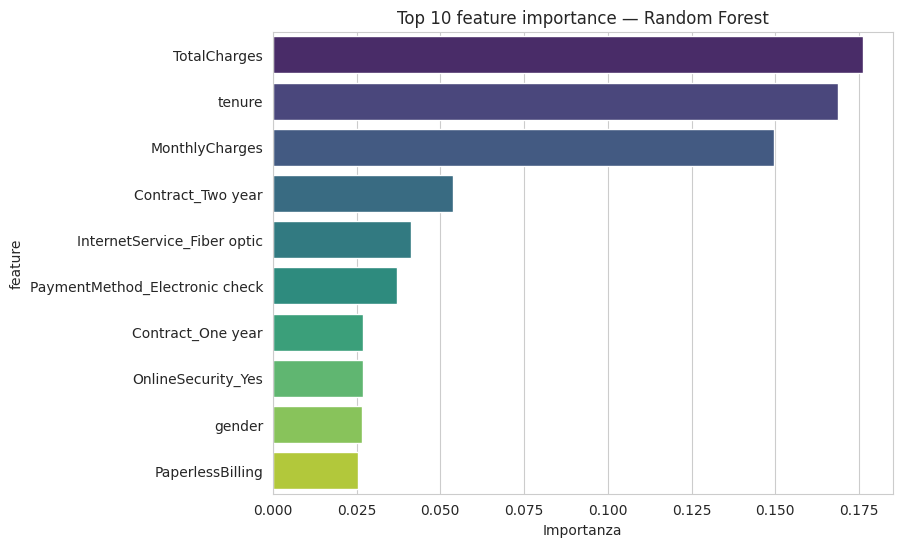

,feature,importance
8,TotalCharges,0.176231
4,tenure,0.168592
7,MonthlyCharges,0.149664
26,Contract_Two year,0.053927
11,InternetService_Fiber optic,0.041338
28,PaymentMethod_Electronic check,0.037031
25,Contract_One year,0.027011
14,OnlineSecurity_Yes,0.026853
0,gender,0.026531
6,PaperlessBilling,0.025547


In [18]:
importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(data=importance.head(10), x='importance', y='feature', hue='feature', palette='viridis', legend=False)
plt.title('Top 10 feature importance — Random Forest')
plt.xlabel('Importanza')
plt.savefig('../figures/feature_importance_rf.png', dpi=150, bbox_inches='tight')
plt.show()

importance.head(10)


### 7.2 Coefficienti della Regressione Logistica

Nella regressione logistica, i coefficienti indicano la direzione e la forza dell'effetto di ogni feature (dato che le feature sono standardizzate, sono anche confrontabili tra loro in termini di grandezza). Un coefficiente positivo aumenta la probabilità di churn, uno negativo la diminuisce.


In [19]:
coef = pd.DataFrame({
    'feature': X.columns,
    'coefficiente': log_reg.coef_[0]
}).sort_values('coefficiente', ascending=False)

print("Feature che aumentano di più la probabilità di churn:")
print(coef.head(5))
print()
print("Feature che diminuiscono di più la probabilità di churn:")
print(coef.tail(5))


Feature che aumentano di più la probabilità di churn:
                        feature  coefficiente
11  InternetService_Fiber optic      0.783120
8                  TotalCharges      0.515091
24          StreamingMovies_Yes      0.294727
22              StreamingTV_Yes      0.252022
10            MultipleLines_Yes      0.193337

Feature che diminuiscono di più la probabilità di churn:
               feature  coefficiente
14  OnlineSecurity_Yes     -0.123182
25   Contract_One year     -0.298164
26   Contract_Two year     -0.592687
7       MonthlyCharges     -1.019495
4               tenure     -1.156394


**Interpretazione:** sia la feature importance della Random Forest sia i coefficienti della regressione logistica confermano quanto visto in Fase 3: il tipo di contratto (in particolare avere un contratto a due anni, che riduce fortemente la probabilità di churn) e `tenure` sono tra i fattori più influenti. Questo è rassicurante: due modelli molto diversi tra loro (uno lineare, uno basato su alberi) concordano sui fattori principali, il che rende il risultato più affidabile.

Attenzione: la feature importance e i coefficienti non dimostrano un rapporto di causa-effetto, solo un'associazione statistica appresa dal modello.


## 8. Riflessioni critiche sui risultati

**Punti di forza:** tutti e tre i modelli superano ampiamente un classificatore banale che prevede sempre "No churn" (che avrebbe recall 0 sulla classe di interesse). La regressione logistica e la Random Forest, grazie a `class_weight='balanced'`, riescono a individuare la maggior parte dei clienti a rischio.

**Limiti:**
- Il k-NN è penalizzato dallo squilibrio di classe e dalla dimensionalità (dopo il one-hot encoding abbiamo molte più colonne rispetto al dataset visto a lezione), il che rende le distanze meno informative.
- Nessuno dei modelli raggiunge una precision molto alta sulla classe Churn: significa che, se l'azienda contattasse tutti i clienti segnalati a rischio, molti di questi in realtà sarebbero rimasti comunque (falsi positivi). Va valutato il costo pratico di questo tipo di errore rispetto a quello di non contattare un cliente che invece abbandonerà.

**Interpretabilità:** la regressione logistica è il modello più facile da spiegare (coefficienti diretti), la Random Forest offre comunque la feature importance ma è meno trasparente nel dettaglio, il k-NN è il meno interpretabile dei tre (non ha coefficienti né importanza delle feature).

**Costo computazionale:** la Random Forest con 200 alberi è il modello più lento da addestrare tra i tre, anche se su un dataset di questa dimensione (7043 righe) la differenza è comunque contenuta in pochi secondi.
